İlk işlenmiş yorum örneği:
stay cheap narrow room know needed room could spend night look hotel cheap room enough room really small bed really small except mini fridge want open large suitcase open bathroom toilet enough room give night provide basic condition stay bed pillow etc comfortable toilet bathroom clean stay night want stay second night room could catch eye night tolerate internet not work room wifi password request location term walk distance everywhere

------------------------------------

Bag-of-Words Matrisi (array):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

BoW Vocabulary:
[('abak', 0), ('abd', 1), ('abi', 2), ('abis', 3), ('able', 4), ('abnormal', 5), ('abnormality', 6), ('abroad', 7), ('absolute', 8), ('absolutely', 9), ('absurd', 10), ('abundance', 11), ('abundant', 12), ('ac', 13), ('acar', 14), ('acasya', 15), ('accent', 16), ('accept', 17), ('acceptable', 18), ('access', 19), ('accessib

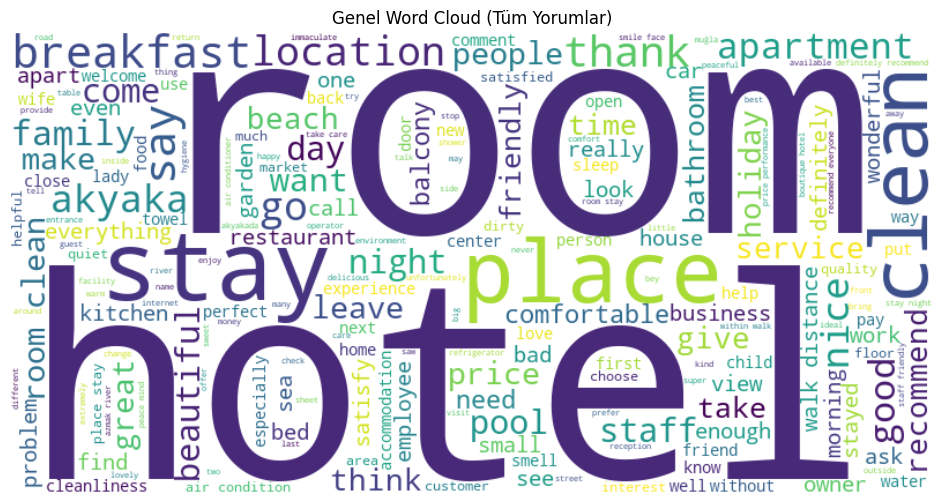

C:\Users\catsu\AppData\Local\Temp\ipykernel_19260\3848597517.py:216: RuntimeWarning: divide by zero encountered in divide
  return C / (rank ** s)
C:\Users\catsu\AppData\Local\Temp\ipykernel_19260\3848597517.py:216: RuntimeWarning: overflow encountered in divide
  return C / (rank ** s)


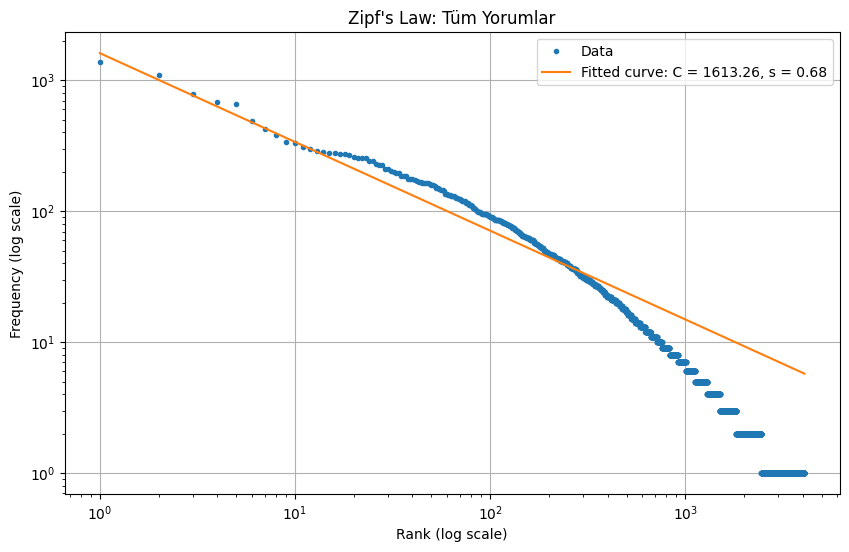

Fitted equation: f(r) = 1613.26 / r^0.68

Tüm işlemler başarıyla tamamlandı!
İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!


In [2]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit
import pandas as pd

# NLP ve metin ön işleme kütüphaneleri
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer

# POS etiketlerini WordNet etiketlerine çevirmek için yardımcı fonksiyon
def get_wordnet_pos(treebank_tag):
    """
    Treebank POS etiketini WordNet etiketine dönüştürür.
    """
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

# Scikit-learn vektörleştiriciler
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# WordCloud
from wordcloud import WordCloud

# Gerekli NLTK verilerini indiriyoruz (ilk çalıştırmada)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

#######################################
# Contraction Genişletme Fonksiyonu
#######################################
contraction_mapping = {
    "cant": "can not",
    "didnt": "did not",
    "dont": "do not",
    "doesnt": "does not",
    "wont": "will not",
    "wouldnt": "would not",
    "shouldnt": "should not",
    "isnt": "is not",
    "arent": "are not",
    "wasnt": "was not",
    "werent": "were not",
    "im": "i am",
    "ive": "i have",
    "id": "i would",  # örnek; ihtiyaca göre ekleyebilirsiniz.
    "youre": "you are",
    "youve": "you have",
    "hes": "he is",
    "shes": "she is",
    "its": "it is",
    "theyre": "they are",
    "theyve": "they have",
    "checkin": "check in",
    "checkout": "check out",
    "superrrrrrrrr": "super",
    "supper": "super",
    "checkout": "check out",
    "apt": "apartment",
    "veey": "very",
    "beautıful": "beautiful",
    "anil": "anıl",
    "mugla": "muğla",
    "oludeniz": "ölüdeniz",
    "turkishstyle": "turkish style",
    "wellequiped": "well equiped",
    "niceeee": "nice",
    "priceperformance": "price performance",
    # Diğer kısaltmaları da ekleyebilirsiniz.
}

def expand_contractions(text):
    """
    Metindeki kısaltmaları genişletir.
    Örneğin, "cant" -> "can not", "didnt" -> "did not" vb.
    """
    for contraction, expansion in contraction_mapping.items():
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
    return text

#######################################
# Fonksiyonlar: Temizleme, Tokenizasyon, Stopword çıkarımı, Stemming, Lemmatizasyon
#######################################

def normalize_text(text):
    """
    Metni casefold (küçük harfe çevirme) yapar ve
    a-z ile Türkçe karakterleri (ç, ğ, ı, ö, ş, ü) içeren kelimeleri yakalar.
    Böylece sayılar atılır.
    """
    text = text.casefold()  # Türkçe için casefold tercih edilir
    tokens = re.findall(r'[a-zçğıöşü]+', text)
    return " ".join(tokens)

def remove_stopwords(text, lang="english"):
    """
    Tokenize edilmiş metinden nltk stopword listesini çıkarır.
    """
    stop_words = set(stopwords.words(lang))
    for word in ["not"]:
        stop_words.discard(word)
    tokens = text.split()
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return " ".join(filtered_tokens)

def stem_text(text):
    """
    Tokenize edilmiş metindeki kelimeleri Porter Stemmer kullanarak köklerine indirger.
    """
    stemmer = PorterStemmer()
    tokens = text.split()
    stemmed = [stemmer.stem(token) for token in tokens]
    return " ".join(stemmed)

def lemmatize_text(text):
    """
    Metni tokenize edip, NLTK'nin POS etiketlemesini kullanarak,
    her kelimeyi uygun WordNet POS etiketiyle lemmatize eder.
    """
    lemmatizer = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(token, pos=get_wordnet_pos(pos)) for token, pos in pos_tags]
    return " ".join(lemmatized)

#######################################
# CSV Dosyasından Veri Okuma ve Ön İşleme
#######################################

# CSV dosyasını okuyun (dosya yolunu kendi dosyanızla değiştirin)
csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_nlp_deepl.csv"
df = pd.read_csv(csv_path, engine="python", encoding='utf-8')

# "final_review" sütunundaki boş değerleri "" ile doldurup listeye dönüştürün
reviews = df["processed_review"].fillna("").tolist()

# İhtiyacınıza göre tüm yorumları ya da bir örneklem (örneğin ilk 50) kullanabilirsiniz:
sample_reviews = reviews  # veya reviews[:50]

# Adım 1: Yorumları normalize edip temizleyelim.
clean_reviews = [normalize_text(review) for review in sample_reviews]

# Kısaltmaları genişletelim (normalize_text'ten sonra, çünkü normalize metin kısaltmaları "cant", "didnt" şeklinde bırakır)
expanded_reviews = [expand_contractions(review) for review in clean_reviews]

# Stopword'leri çıkaralım.
reduced_reviews = [remove_stopwords(review) for review in expanded_reviews]

# Adım 2: Lemmatizasyon uygulayalım.
processed_reviews = [lemmatize_text(review) for review in reduced_reviews]

# Örnek olarak ilk işlenmiş yorumu çıktı verelim:
print("İlk işlenmiş yorum örneği:")
print(processed_reviews[0])
print("\n------------------------------------\n")

#######################################
# Adım 3: Belge Temsili - Bag-of-Words (BoW) ve TF-IDF
#######################################

# BoW Modeli: Vektörleştirici, token pattern olarak boşluklardan bölecek şekilde ayarlanıyor.
bow_vectorizer = CountVectorizer(token_pattern=r'\S+')
bow_matrix = bow_vectorizer.fit_transform(processed_reviews)
print("Bag-of-Words Matrisi (array):")
print(bow_matrix.toarray())
print("\nBoW Vocabulary:")
vocab = sorted(bow_vectorizer.vocabulary_.items(), key=lambda x: x[1])
print(vocab)

# TF-IDF Modeli
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\S+')
tfidf_matrix = tfidf_vectorizer.fit_transform(processed_reviews)
print("\nTF-IDF Matrisi (array):")
print(tfidf_matrix.toarray())

#######################################
# Adım 4: Word Cloud Oluşturma (Tüm Yorumlar İçin)
#######################################

combined_text = " ".join(processed_reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(combined_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Genel Word Cloud (Tüm Yorumlar)")
plt.show()

#######################################
# Adım 5: Zipf's Law Analizi (Genel Kelime Frekansları)
#######################################

def plot_zipf(frequencies, title="Zipf's Law", output_path=None):
    # Kelime frekanslarını en çoktan en aza sırala
    sorted_freq = frequencies.most_common()
    ranks = np.arange(1, len(sorted_freq) + 1)
    freq_values = np.array([freq for _, freq in sorted_freq])
    
    # Zipf fonksiyonu: f(r) = C / r^s
    def zipf_law(rank, C, s):
        return C / (rank ** s)
    
    popt, _ = curve_fit(zipf_law, ranks, freq_values, maxfev=10000)
    C, s = popt

    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, freq_values, marker=".", linestyle="none", label="Data")
    plt.loglog(ranks, zipf_law(ranks, *popt), label=f"Fitted curve: C = {C:.2f}, s = {s:.2f}")
    plt.title(title)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.legend()
    plt.grid(True)
    if output_path:
        plt.savefig(output_path)
    plt.show()
    print(f"Fitted equation: f(r) = {C:.2f} / r^{s:.2f}")

all_tokens = combined_text.split()
all_freq = Counter(all_tokens)
plot_zipf(all_freq, title="Zipf's Law: Tüm Yorumlar")

#######################################
# İşlemlerin Sonu
#######################################
print("\nTüm işlemler başarıyla tamamlandı!")

# -------------------------------
# İşlenmiş yorumları DataFrame'e yeni bir sütun olarak ekleyip CSV'ye yazma
# -------------------------------
df["processed_final_review"] = processed_reviews
output_csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_nlp_deepl.csv"
df.to_csv(output_csv_path, index=False, encoding='utf-8')
print("İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!")


In [14]:
print("Clean review:", clean_reviews[0])
print("Expanded review:", expanded_reviews[0])
print("Reduced review:", reduced_reviews[0])
print("Processed review:", processed_reviews[0])


Clean review: stayed cheap narrow room knew needed room could spend night looking hotel cheap room enough room really small bed really small except mini fridge want open large suitcase cant open bathroom toilet enough room give night provides basic condition staying bed pillow comfortable toilet bathroom clean stayed night wanted stay second night room could catch eye night tolerated internet work room wifi password requested location term walking distance everywhere
Expanded review: stayed cheap narrow room knew needed room could spend night looking hotel cheap room enough room really small bed really small except mini fridge want open large suitcase can not open bathroom toilet enough room give night provides basic condition staying bed pillow comfortable toilet bathroom clean stayed night wanted stay second night room could catch eye night tolerated internet work room wifi password requested location term walking distance everywhere
Reduced review: stayed cheap narrow room knew need

İlk işlenmiş yorum örneği:
stay cheap narrow room know needed room could spend night look hotel cheap room enough room really small bed really small except mini fridge want open large suitcase open bathroom toilet enough room give night provi basic condition stay bed pillow comfortable toilet bathroom clean stay night want stay second night room could catch eye night tolera internet not work room wifi password request location term walk distance everywhere

------------------------------------

Lemmatizasyon test sonuçları:
account -> account
accounting -> accounting
running -> run
ran -> ran
better -> well
best -> best
Bag-of-Words Matrisi (array):
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

BoW Vocabulary:
[('abak', 0), ('abd', 1), ('abi', 2), ('able', 3), ('abnormal', 4), ('abnormality', 5), ('abroad', 6), ('absolu', 7), ('absolutely', 8), ('absurd', 9), ('abundance', 10), ('abundant', 11), ('ac', 12), ('ac

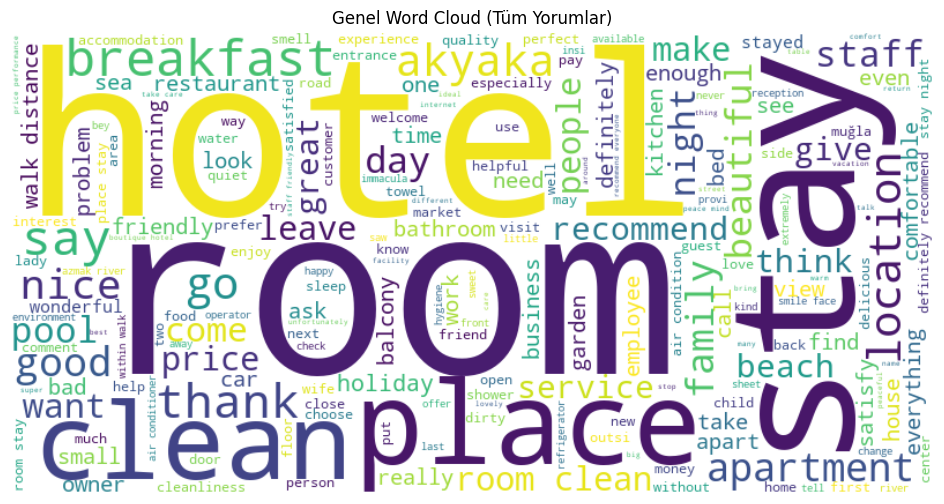

Tüm kelimelerin frekansları:
room: 1369
hotel: 1103
stay: 789
clean: 681
place: 661
breakfast: 493
location: 428
say: 383
akyaka: 358
go: 337
nice: 333
recommend: 301
night: 288
would: 285
good: 279
day: 277
friendly: 276
thank: 275
price: 268
family: 261
staff: 257
like: 257
apartment: 253
pool: 241
beautiful: 240
not: 231
make: 226
beach: 226
sea: 209
take: 202
walk: 198
owner: 197
come: 195
want: 194
people: 187
holiday: 185
close: 185
give: 177
bed: 176
think: 176
comfortable: 172
great: 170
time: 167
need: 166
service: 165
one: 165
definitely: 164
leave: 164
business: 161
could: 160
view: 159
small: 157
see: 151
everything: 150
apart: 149
water: 149
problem: 145
bathroom: 144
air: 135
without: 135
shower: 133
distance: 132
really: 130
find: 130
home: 130
center: 128
work: 127
even: 127
car: 126
thanks: 123
restaurant: 122
balcony: 120
kitchen: 119
also: 119
next: 116
look: 115
house: 115
employee: 112
cleanliness: 111
garden: 111
stayed: 109
enough: 105
floor: 105
bad: 104
child: 

C:\Users\catsu\AppData\Local\Temp\ipykernel_14444\249311777.py:227: RuntimeWarning: divide by zero encountered in divide
  return C / (rank ** s)
C:\Users\catsu\AppData\Local\Temp\ipykernel_14444\249311777.py:227: RuntimeWarning: overflow encountered in divide
  return C / (rank ** s)


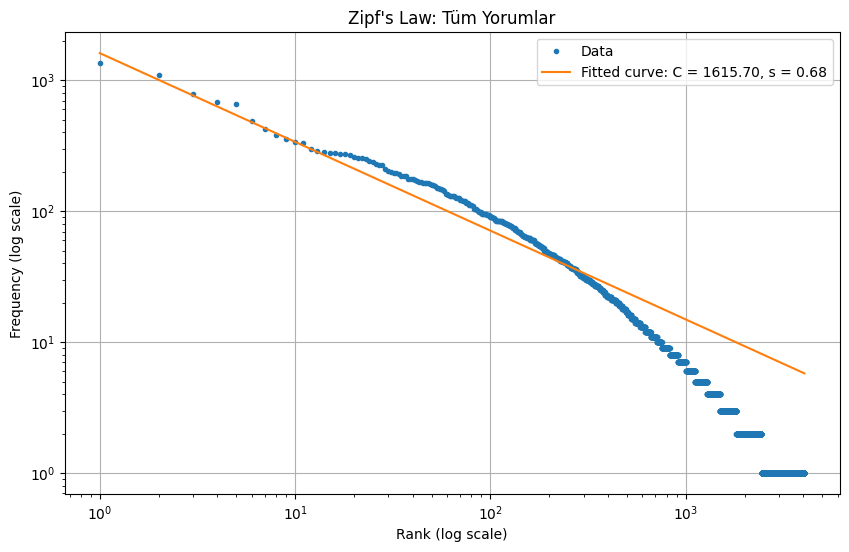

Fitted equation: f(r) = 1615.70 / r^0.68

Tüm işlemler başarıyla tamamlandı!
İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!


In [6]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit
import pandas as pd
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

# Gerekli NLTK verilerini indiriyoruz (ilk çalıştırmada)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

#######################################
# POS etiketlerini WordNet etiketlerine çeviren yardımcı fonksiyon
#######################################
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

#######################################
# Contraction (kısaltma) genişletme
#######################################
contraction_mapping = {
    "cant": "can not",
    "didnt": "did not",
    "dont": "do not",
    "doesnt": "does not",
    "wont": "will not",
    "wouldnt": "would not",
    "shouldnt": "should not",
    "couldnt:":"could not",
    "isnt": "is not",
    "arent": "are not",
    "wasnt": "was not",
    "werent": "were not",
    "im": "i am",
    "ive": "i have",
    "id": "i would",
    "youre": "you are",
    "youve": "you have",
    "hes": "he is",
    "shes": "she is",
    "its": "it is",
    "theyre": "they are",
    "theyve": "they have",
    "checkin": "check in",
    "checkout": "check out",
    "superrrrrrrrr": "super",
    "supper": "super",
    "apt": "apartment",
    "veey": "very",
    "acasya":"akasya",
    "beautıful": "beautiful",
    "anil": "anıl",
    "absolu": "absolutely",
    "mugla": "muğla",
    "oludeniz": "ölüdeniz",
    "turkishstyle": "turkish style",
    "wellequiped": "well equiped",
    "niceeee": "nice",
    "abis": "abi",
    "accommoda":"accomodation",
    "priceperformance": "price performance",
    # İhtiyaç duyarsanız diğer kısaltmaları da ekleyebilirsiniz.
}

def expand_contractions(text):
    for contraction, expansion in contraction_mapping.items():
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
    return text

#######################################
# Metin Temizleme, Normalize Etme, Stopword Çıkarma, Lemmatizasyon
#######################################
def normalize_text(text):
    """
    Metni küçük harfe çevirip a-z ve Türkçe karakterleri (ç, ğ, ı, ö, ş, ü) yakalar.
    Böylece sadece kelimeler kalır.
    """
    text = text.casefold()
    tokens = re.findall(r'[a-zçğıöşü]+', text)
    return " ".join(tokens)

def remove_stopwords(text, lang="english"):
    stop_words = set(stopwords.words(lang))
    stop_words.discard("not")  # Eğer "not" gibi kelimeler önemliyse kaldırmayın
    extra_stopwords_eng = {
    "km", "going", "u", "im", "höt", "year", "old", "minutes","lira",
    "18mpbs", "us", "lets", "come", "theres", "min", "ms", "mr", "yes", "11pm",
    "2am", "10pm", "id", "etc", "motors", "tl", "3rd", "its","etc"
    }
    stop_words.update(extra_stopwords_eng)
    tokens = text.split()
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return " ".join(filtered_tokens)

def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(token, pos=get_wordnet_pos(pos)) for token, pos in pos_tags]
    return " ".join(lemmatized)

#######################################
# Türkçe yer (konum) eklerini kaldırma
#######################################
def remove_turkish_locative_suffix(word):
    """
    Kelimenin sonundaki, Türkçe'de sıklıkla kullanılan yer eklerini kaldırır.
    Örneğin: 'fethiyede' -> 'fethiye', 'muğladaki' -> 'muğla'
    """
    pattern = re.compile(r"^(.*?)(daki|deki|dakı|da|de|ta|te)$")
    match = pattern.match(word)
    if match:
        base = match.group(1)
        if len(base) > 2:
            return base
    return word

def remove_locative_suffixes(text):
    tokens = text.split()
    new_tokens = [remove_turkish_locative_suffix(token) for token in tokens]
    return " ".join(new_tokens)

#######################################
# CSV Dosyasından Veri Okuma ve Ön İşleme
#######################################
csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl.csv"
df = pd.read_csv(csv_path, engine="python", encoding="utf-8")

# "processed_review" sütunundaki boş değerleri boş string ile doldurup listeye dönüştürün
reviews = df["processed_review"].fillna("").tolist()
sample_reviews = reviews  # Tüm yorumları kullanabilirsiniz ya da örneklem seçebilirsiniz

# Adım 1: Yorumları normalize edip temizleyelim.
clean_reviews = [normalize_text(review) for review in sample_reviews]
expanded_reviews = [expand_contractions(review) for review in clean_reviews]
reduced_reviews = [remove_stopwords(review) for review in expanded_reviews]

# Adım 2: Lemmatizasyon
processed_reviews = [lemmatize_text(review) for review in reduced_reviews]

# Yeni Adım: Özel isimlerdeki yer eklerini kaldırma (örneğin, fethiyede -> fethiye)
final_reviews = [remove_locative_suffixes(review) for review in processed_reviews]

# Örnek olarak ilk işlenmiş yorumu çıktı verelim:
print("İlk işlenmiş yorum örneği:")
print(final_reviews[0])
print("\n------------------------------------\n")

# Örnek kelimeler
test_words = ["account", "accounting", "running", "ran", "better", "best"]
print("Lemmatizasyon test sonuçları:")
for word in test_words:
    lemmatized_word = lemmatize_text(word)
    print(f"{word} -> {lemmatized_word}")
# Bu sonuçlara bakarak; örneğin "accounting" in "a

#######################################
# Adım 3: Belge Temsili - Bag-of-Words (BoW) ve TF-IDF
#######################################
bow_vectorizer = CountVectorizer(token_pattern=r'\S+')
bow_matrix = bow_vectorizer.fit_transform(final_reviews)
print("Bag-of-Words Matrisi (array):")
print(bow_matrix.toarray())
vocab = sorted(bow_vectorizer.vocabulary_.items(), key=lambda x: x[1])
print("\nBoW Vocabulary:")
print(vocab)

tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\S+')
tfidf_matrix = tfidf_vectorizer.fit_transform(final_reviews)
print("\nTF-IDF Matrisi (array):")
print(tfidf_matrix.toarray())

#######################################
# Adım 4: Word Cloud Oluşturma
#######################################
combined_text = " ".join(final_reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(combined_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Genel Word Cloud (Tüm Yorumlar)")
plt.show()

# Tüm işlenmiş yorumlardaki kelimeleri tokenize edip, frekanslarını hesaplayalım.
all_tokens = []
for review in final_reviews:
    # Her yorumdaki kelimeleri boşluklardan ayırarak listeye ekliyoruz.
    all_tokens.extend(review.split())

# Kelime frekanslarını hesaplayalım.
word_counts = Counter(all_tokens)

# Kelimeleri frekanslarına göre sıralayıp, hepsini bastıralım.
print("Tüm kelimelerin frekansları:")
for word, count in word_counts.most_common():
    print(f"{word}: {count}")


#######################################
# Adım 5: Zipf's Law Analizi
#######################################
def plot_zipf(frequencies, title="Zipf's Law", output_path=None):
    sorted_freq = frequencies.most_common()
    ranks = np.arange(1, len(sorted_freq) + 1)
    freq_values = np.array([freq for _, freq in sorted_freq])
    
    def zipf_law(rank, C, s):
        return C / (rank ** s)
    
    popt, _ = curve_fit(zipf_law, ranks, freq_values, maxfev=10000)
    C, s = popt

    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, freq_values, marker=".", linestyle="none", label="Data")
    plt.loglog(ranks, zipf_law(ranks, *popt), label=f"Fitted curve: C = {C:.2f}, s = {s:.2f}")
    plt.title(title)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.legend()
    plt.grid(True)
    if output_path:
        plt.savefig(output_path)
    plt.show()
    print(f"Fitted equation: f(r) = {C:.2f} / r^{s:.2f}")

all_tokens = combined_text.split()
all_freq = Counter(all_tokens)
plot_zipf(all_freq, title="Zipf's Law: Tüm Yorumlar")

print("\nTüm işlemler başarıyla tamamlandı!")

#######################################
# İşlenmiş Yorumları CSV'ye Kaydetme (Türkçe karakter bozulmasın)
#######################################
# Türkçe karakterlerin sorunsuz görüntülenmesi için 'utf-8-sig' encoding kullanabilirsiniz.
df["processed_final_review"] = final_reviews
output_csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl.csv"
df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")
print("İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!")


Temizleme işlemi öncesi token frekansları:
room: 1370
hotel: 1106
place: 656
clean: 564
breakfast: 496
stayed: 462
location: 434
stay: 391
akyaka: 336
nice: 333
night: 291
thank: 280
would: 280
friendly: 278
day: 277
recommend: 274
good: 273
family: 266
price: 263
staff: 257
apartment: 257
pool: 242
beautiful: 241
beach: 228
said: 220
like: 217
sea: 214
owner: 200
go: 199
people: 188
holiday: 185
bed: 178
comfortable: 172
great: 170
time: 170
service: 167
definitely: 167
one: 166
close: 165
business: 164
could: 160
apart: 160
view: 160
came: 155
small: 153
everything: 151
water: 150
satisfied: 149
want: 147
say: 146
problem: 145
bathroom: 144
air: 141
went: 137
without: 136
distance: 133
shower: 133
walking: 132
need: 131
really: 130
home: 130
center: 130
made: 128
conditioner: 126
thanks: 125
restaurant: 125
car: 125
balcony: 122
kitchen: 119
also: 119
house: 117
next: 116
garden: 114
see: 113
parking: 113
employee: 112
cleanliness: 112
think: 111
floor: 107
enough: 106
even: 102
left

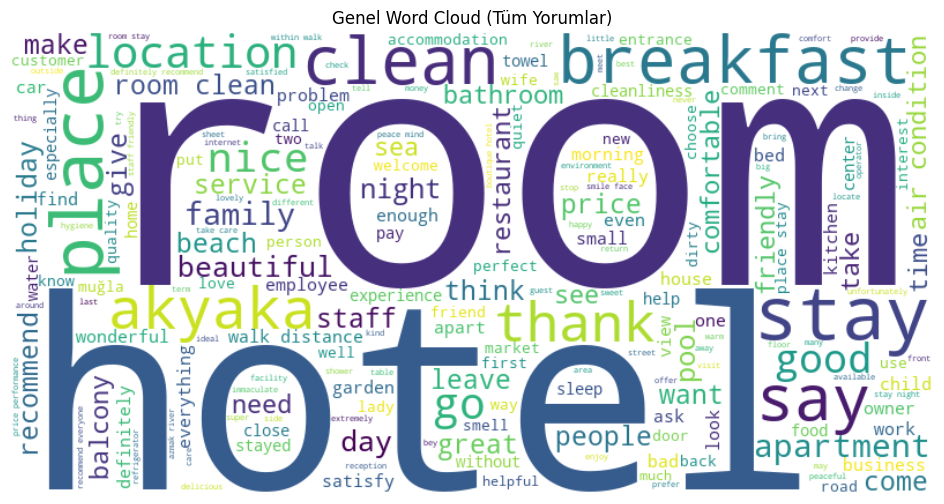

C:\Users\catsu\AppData\Local\Temp\ipykernel_18076\3889352641.py:300: RuntimeWarning: divide by zero encountered in divide
  return C / (rank ** s)
C:\Users\catsu\AppData\Local\Temp\ipykernel_18076\3889352641.py:300: RuntimeWarning: overflow encountered in divide
  return C / (rank ** s)


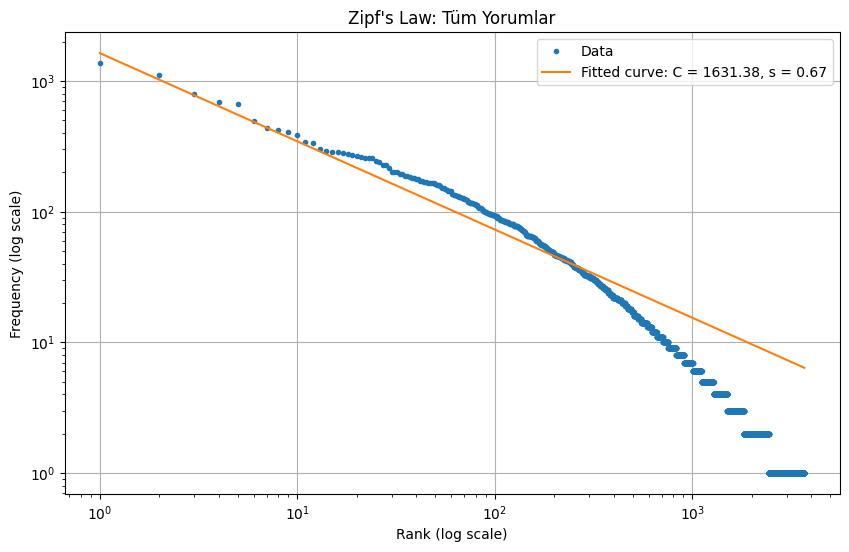

Fitted equation: f(r) = 1631.38 / r^0.67

Tüm işlemler başarıyla tamamlandı!
İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!


In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

import re
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.optimize import curve_fit
import pandas as pd
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud

# Gerekli NLTK verilerini indiriyoruz (ilk çalıştırmada)
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)

#######################################
# POS etiketlerini WordNet etiketlerine çeviren yardımcı fonksiyon
#######################################
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

#######################################
# Contraction (kısaltma) genişletme
#######################################
contraction_mapping = {
    "cant": "can not",
    "didnt": "did not",
    "dont": "do not",
    "doesnt": "does not",
    "wont": "will not",
    "wouldnt": "would not",
    "shouldnt": "should not",
    "couldnt": "could not",
    "isnt": "is not",
    "arent": "are not",
    "wasnt": "was not",
    "werent": "were not",
    "im": "i am",
    "ive": "i have",
    "id": "i would",
    "youre": "you are",
    "youve": "you have",
    "hes": "he is",
    "shes": "she is",
    "its": "it is",
    "theyre": "they are",
    "omer":"ömer",
    "ran":"run",
    "theyve": "they have",
    "checkin": "check in",
    "checkout": "check out",
    "superrrrrrrrr": "super",
    "supper": "super",
    "apt": "apartment",
    "ac": "air condition", 
    "veey": "very",
    "tzatziki": "cacık",
    "wc": "toilet",
    "ok":"okey",
    "acasya": "akasya",
    "beautıful": "beautiful",
    "anil": "anıl",
    "slept":"sleep",
    "childrens":"children",
    "absolu": "absolutely",
    "mugla": "muğla",
    "oludeniz": "ölüdeniz",
    "saklıkoy": "saklıköy",
    "niceeee": "nice",
    "relaxed": "relax",
    "thanks": "thank",
    "abis": "abi",
    "accommoda": "accomodation",
    # Diğer kısaltmaları ihtiyaca göre ekleyebilirsiniz.
}

def expand_contractions(text):
    for contraction, expansion in contraction_mapping.items():
        pattern = r'\b' + re.escape(contraction) + r'\b'
        text = re.sub(pattern, expansion, text)
    return text

#######################################
# Korumalı İfadeler (protected expressions) – Birleştirilmek istenen kalıp ifadeler
#######################################
protected_expressions = {
    "wellmaintained": "well maintained",
    "warmblooded": "warm blooded",
    "priceperformance": "price performance",
    "fulllength": "full length",
    "turkishstyle": "turkish style",
    "wellintentioned": "well intentioned",
    "wellequiped": "well equiped",
    "sugarfree": "sugar free",
    "glutenfree": "gluten free",
    "brotherinlaw":"brother in law",
    "courtyardgarden": "courtyard garden",
    "roadtrip": "road trip",
    "selfcatering": "self catering",
    "selfrespect": "self respect",
    "roomsized": "room size",
    "settop": "set top",
    "roomspecific": "room specific",
    "homelike": "home like",
    "nicelooking": "nice looking",
    "dungeonlike": "dungeon like",
    "natureloving": "nature loving",
    "wholeheartedly": "whole heartedly",
    "childfriendly": "child friendly",
    "animalfriendly": "animal friendly",
    "familyfriendly": "family friendly",
    "wellappointed": "well appointed",
    "bedtime": "bed time",
    "warmhearted": "warm hearted",
    "air conditioner": "air condition",
    "cacık": "cacık",
    "all inclusive": "all inclusive",
    "overcrowded": "overcrowded",
    "parking lot": "parking lot",
    "sigara böreği": "sigara böreği",
    "ozgem": "özgem",
    "oren": "ören",
    "scar":"scared",
    "yoğurtlama": "yoğurtlama",
    "mantı": "mantı",
    "sorbet": "şerbet", 
    "mucver":"mücver",
    "yogurt": "yoğurt",
    "sarıyer börekçisi": "sarıyer börekçisi",
    "kokoreç": "kokoreç"  # İhtiyaç duyarsanız diğer ifadeleri ekleyin.
}

def protect_expressions(text):
    for phrase, replacement in protected_expressions.items():
        text = re.sub(re.escape(phrase), replacement, text, flags=re.IGNORECASE)
    return text

#######################################
# Metin Temizleme, Normalize Etme, Stopword Çıkarma, Lemmatizasyon
#######################################
def normalize_text(text):
    """
    Metni küçük harfe çevirir ve a-z ile Türkçe karakterleri (ç, ğ, ı, ö, ş, ü) içeren kelimeleri yakalar.
    Böylece sadece kelimeler kalır.
    """
    text = text.casefold()
    # Önce korumalı ifadeleri birleştir
    text = protect_expressions(text)
    tokens = re.findall(r'[a-zçğıöşü]+', text)
    return " ".join(tokens)

def remove_stopwords(text, lang="english"):
    stop_words = set(stopwords.words(lang))
    for w in ["not", "with", "worst"]:
        stop_words.discard(w)
    extra_stopwords_eng = {
        "km", "going", "u", "eg","ey","el","m","et","te","en","th","cm","b","m","bm"
        "dak","im","r","month","liter","lira","fp", "m","gor","fk","gezenkali",
        "minu","today","yayoz","friday","karcan","google","höt", "year", "old", "minutes", "lira",
        "18mpbs", "us", "lets", "come", "theres", "min", "ms", "mr", "yes", "11pm",
        "2am", "10pm", "id", "etc", "motors", "tl", "3rd", "its", "etc"
    }
    stop_words.update(extra_stopwords_eng)
    tokens = text.split()
    filtered_tokens = [token for token in tokens if token not in stop_words]
    return " ".join(filtered_tokens)

def lemmatize_text(text):
    lemmatizer = WordNetLemmatizer()
    tokens = nltk.word_tokenize(text)
    pos_tags = nltk.pos_tag(tokens)
    lemmatized = [lemmatizer.lemmatize(token, pos=get_wordnet_pos(pos)) for token, pos in pos_tags]
    return " ".join(lemmatized)

#######################################
# Türkçe yer (konum) eklerini kaldırma (yalnızca belirli özel isimlere uygulanacak)
#######################################
# Özel isimler için bilinen konum isimlerini tanımlıyoruz.
known_locations = {"fethiye", "muğla", "akyaka", "ölüdeniz", "aksak"}

def remove_turkish_locative_suffix(word):
    """
    Sadece bilinen Türkçe konum isimlerine uygulanır.
    Örneğin: 'fethiyede' -> 'fethiye', 'muğladaki' -> 'muğla', 'akyakadaki' -> 'akyaka'
    Eğer kelime bilinen konum ismiyle başlamıyorsa değişiklik yapılmaz.
    """
    word_lower = word.lower()
    for loc in known_locations:
        # Eğer kelime, konum isminden başlayıp sonra tanınan eklerden birini içeriyorsa:
        pattern = re.compile(r"^(" + re.escape(loc) + r")(daki|deki|dakı|ya|da|de|ta|te)$")
        match = pattern.match(word_lower)
        if match:
            return match.group(1)
    return word

def remove_locative_suffixes(text):
    tokens = text.split()
    new_tokens = [remove_turkish_locative_suffix(token) for token in tokens]
    return " ".join(new_tokens)

#######################################
# CSV Dosyasından Veri Okuma ve Ön İşleme
#######################################
csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv"
df = pd.read_csv(csv_path, engine="python", encoding="utf-8")

# "processed_review" sütunundaki boş değerleri boş string ile doldurup listeye dönüştürün
reviews = df["processed_review"].fillna("").tolist()
sample_reviews = reviews  # Tüm yorumlar veya örneklem seçilebilir

# --- Temizleme İşlemleri (Lemmatizasyon, vs. öncesi) ---
# Korumalı ifadeler uygulanmadan, yalnızca normalize edip token’ları ayırıp frekansları görelim.
pre_clean_tokens = []
for review in sample_reviews:
    temp = review.casefold()
    # Not: Bu aşamada contraction genişletme veya stopword çıkarma yapılmıyor.
    tokens = re.findall(r'[a-zçğıöşü]+', temp)
    pre_clean_tokens.extend(tokens)
print("Temizleme işlemi öncesi token frekansları:")
for word, count in Counter(pre_clean_tokens).most_common():
    print(f"{word}: {count}")
print("\n------------------------------------\n")

# Adım 1: Yorumları normalize edip temizleyelim.
clean_reviews = [normalize_text(review) for review in sample_reviews]
expanded_reviews = [expand_contractions(review) for review in clean_reviews]
reduced_reviews = [remove_stopwords(review) for review in expanded_reviews]

# Adım 2: Lemmatizasyon
processed_reviews = [lemmatize_text(review) for review in reduced_reviews]

# Yeni Adım: Özel isimlerdeki yer eklerini kaldırma (örn. fethiyede -> fethiye)
final_reviews = [remove_locative_suffixes(review) for review in processed_reviews]

# Örnek olarak ilk işlenmiş yorumu çıktı verelim:
print("İlk işlenmiş yorum örneği:")
print(final_reviews[0])
print("\n------------------------------------\n")

# --- Temizleme İşlemleri Sonrası Token Frekansları ---
post_clean_tokens = []
for review in final_reviews:
    post_clean_tokens.extend(review.split())
print("Temizleme işlemi sonrası token frekansları:")
for word, count in Counter(post_clean_tokens).most_common():
    print(f"{word}: {count}")
print("\n------------------------------------\n")

#######################################
# Adım 3: Belge Temsili - Bag-of-Words (BoW) ve TF-IDF
#######################################
bow_vectorizer = CountVectorizer(token_pattern=r'\S+')
bow_matrix = bow_vectorizer.fit_transform(final_reviews)
print("Bag-of-Words Matrisi (array):")
print(bow_matrix.toarray())
vocab = sorted(bow_vectorizer.vocabulary_.items(), key=lambda x: x[1])
print("\nBoW Vocabulary:")
print(vocab)

tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\S+')
tfidf_matrix = tfidf_vectorizer.fit_transform(final_reviews)
print("\nTF-IDF Matrisi (array):")
print(tfidf_matrix.toarray())

#######################################
# Adım 4: Word Cloud Oluşturma
#######################################
combined_text = " ".join(final_reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(combined_text)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Genel Word Cloud (Tüm Yorumlar)")
plt.show()

#######################################
# Adım 5: Zipf's Law Analizi
#######################################
def plot_zipf(frequencies, title="Zipf's Law", output_path=None):
    sorted_freq = frequencies.most_common()
    ranks = np.arange(1, len(sorted_freq) + 1)
    freq_values = np.array([freq for _, freq in sorted_freq])
    
    def zipf_law(rank, C, s):
        return C / (rank ** s)
    
    popt, _ = curve_fit(zipf_law, ranks, freq_values, maxfev=10000)
    C, s = popt

    plt.figure(figsize=(10, 6))
    plt.loglog(ranks, freq_values, marker=".", linestyle="none", label="Data")
    plt.loglog(ranks, zipf_law(ranks, *popt), label=f"Fitted curve: C = {C:.2f}, s = {s:.2f}")
    plt.title(title)
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.legend()
    plt.grid(True)
    if output_path:
        plt.savefig(output_path)
    plt.show()
    print(f"Fitted equation: f(r) = {C:.2f} / r^{s:.2f}")

all_tokens = combined_text.split()
all_freq = Counter(all_tokens)
plot_zipf(all_freq, title="Zipf's Law: Tüm Yorumlar")

print("\nTüm işlemler başarıyla tamamlandı!")

#######################################
# İşlenmiş Yorumları CSV'ye Kaydetme (Türkçe karakter bozulmasın)
#######################################
df["processed_final_review"] = final_reviews
output_csv_path = "C:\\Users\\catsu\\PycharmProjects\\scrappyhotel\\final_processed_reviews_deepl_use.csv"
df.to_csv(output_csv_path, index=False, encoding="utf-8-sig")
print("İşlenmiş yorumlar 'processed_final_review' sütunu olarak CSV dosyasına kaydedildi!")
